# Assessing Trends and Impacts of Floods using Multivariable Logistic Regression

---
Literature:

Delforge, D., Wathelet, V., Below, R., Sofia, C. L., Tonnelier, M., von Loenhout, J. A. F. and Speybroeck, N. (2025). EM-DAT: the Emergency Events Database. *International Journal of Disaster Risk Reduction, 124*, 1-17. https://doi.org/10.1016/j.ijdrr.2025.105509

Liu, Q., Du, M., Wang, Y., Deng, J., Yan, W., Qin, C., Liu, M. & Liu, J. (2024). Global, regional and national trends and impacts of natural floods, 1990-2022. *Bull World Health Organ, 102*(6), 410-420. https://doi.org/10.2471/BLT.23.290243

---

In this notebook, the methodology of Liu et al. (2024) is reproduced, who study flood trends at different spatial levels as well as factors affecting the number of flood-related deaths. Firstly, the analyze global, regional and national trends of floods from 1990 to 2022 using a descriptive analysis. Secondly, they use multivariate logistic regression to investigate factors associated with flood-related deaths. 

Similarly as Liu et al. (2024), EM-DAT data is combined with demographic data. Specifically, this notebook uses the data `floods_with_population.csv`, which combines

1.  Disaster-related data from EM-DAT (International Disaster Database), 1990 - 2022 (Delforge et al., 2025, retrieved on March 4th, 2026 from https://public.emdat.be)
2. Demographic data from UNdata (UN open database), 1990 - 2022 (retrieved on March 4th, 2026 from https://data.un.org/Data.aspx?d=POP&f=tableCode%3a1)
3. Data on WHO regions from Our World in Data (retrieved on March 5th, 2026 from https://ourworldindata.org/grapher/who-regions?tab=table)

`floods_with_population.csv` includes the following variables:

| Name                              | Type        | Description                                                                                                                | Source |
|-----------------------------------|-------------|----------------------------------------------------------------------------------------------------------------------------|-------------|
| Disaster Subtype                  | string      | The disaster subtype. Options are 'Flood (General)', 'Flash flood', 'Riverine flood', 'Coastal flood'                      | EM-DAT      |
| Country                           | string      | Country where the disaster occurred and had an impact using names from the UN M49 Standard                                 | EM-DAT      |
| Start Year                        | integer     | Year of occurrence of the disaster                                                                                         | EM-DAT      |
| Start Month                       | float       | Month of occurrence of the disaster                                                                                        | EM-DAT      |
| Start Day                         | float       | Day of occurrence of the disaster                                                                                          | EM-DAT      |
| End Year                          | integer     | Year of conclusion of the disaster                                                                                         | EM-DAT      |
| End Month                         | float       | Month of conclusion of the disaster                                                                                        | EM-DAT      |
| End Day                           | float       | Day of conclusion of the disaster                                                                                          | EM-DAT      |
| Total Damage, Adjusted ('000 US$) | float       | Total Damage (’000 US$) adjusted for inflation using the Consumer Price Index (CPI)                                        | EM-DAT      |
| Total Deaths                      | float       | Total fatalities (deceased and missing combined)                                                                           | EM-DAT      |
| Total Affected                    | float       | Total number of affected people (injured, homeless and/or affected)                                                        | EM-DAT      |
| Population                        | float       | Total population of the country (from UNDat)                                                                               | UNdata      |
| WHO Region                        | string      | WHO region. Options are 'Africa', 'Americas', 'Eastern Mediterranean', 'Europe', 'South-East Asia', 'Western Pacific'      | Our World in Data |
| Population (WHO Region)           | float       | Total population of the entire WHO region                                                                                  | Our World in Data & UNdata |

Since the data in EM-DAT has been reported to be particularly biased for disasters prior to 2000 (Delforge et al., 2025), and the population data is missing for many countries for the year 2025, the following analysis exlcusively considers events between 2000 and 2024 (inclusive).

## 0. Data Loading

We begin by loading the required modules and the data into the notebook.

In [1]:
# Import modules
import pandas as pd 
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import calendar
import statsmodels.api as sm

In [2]:
# Load flood data
floods = pd.read_csv("floods_with_population.csv")
floods = floods.rename(columns={"Total Damage, Adjusted ('000 US$)": "Total Damage"})
floods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4126 entries, 0 to 4125
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Disaster Subtype         4126 non-null   object 
 1   Country                  4126 non-null   object 
 2   Start Year               4126 non-null   int64  
 3   Start Month              4125 non-null   float64
 4   Start Day                3854 non-null   float64
 5   End Year                 4126 non-null   int64  
 6   End Month                4125 non-null   float64
 7   End Day                  3865 non-null   float64
 8   Total Damage             1186 non-null   float64
 9   Total Deaths             3019 non-null   float64
 10  Total Affected           3725 non-null   float64
 11  Population               4029 non-null   float64
 12  WHO Region               4004 non-null   object 
 13  Population (WHO Region)  4004 non-null   float64
dtypes: float64(9), int64(2),

## 1. Descriptive Analysis

Following Liu et al. (2024), we begin by aggregating the data `floods` in several ways to enable a descriptive analysis at different spatial and temporal scales. The following three datasets will be created.

### 1.1 `floods_country` 

`floods_country` contains the data aggregated at the country-year level. We sum over the number of affected people (`Total Affected`), the number of deaths (`Total Deaths`) and the economic damage (`Total Damage`) for every combination of `Start Year` and `Country`.

In [3]:
floods_country = floods.groupby(
    ["Country", "Start Year"],
    as_index=False
)[["Total Damage", "Total Deaths", "Total Affected"]].sum()

floods_country.head()

,Country,Start Year,Total Damage,Total Deaths,Total Affected
0,Afghanistan,2002,0.0,81.0,5545.0
1,Afghanistan,2003,0.0,136.0,3753.0
2,Afghanistan,2004,0.0,16.0,4500.0
3,Afghanistan,2005,0.0,283.0,18318.0
4,Afghanistan,2006,0.0,282.0,32975.0


Next, `sort_values()` is used to retrieve the five countries with the highest value for `Total Affected`, `Total Deaths` and `Total Damage` over the entire period, 2000-2024.

In [5]:
# Sum over all years per country
floods_country_full_period = floods_country.groupby("Country", as_index=False)[
    ["Total Damage", "Total Deaths", "Total Affected"]
].sum()

# Get the top 5 countries for `Total Affected`, `Total Deaths`, `Total Damage`
highest_affected = floods_country_full_period.sort_values("Total Affected", ascending=False).head(5)
highest_deaths = floods_country_full_period.sort_values("Total Deaths", ascending=False).head(5)
highest_damage = floods_country_full_period.sort_values("Total Damage", ascending=False).head(5)

print("Top 5 countries by total affected:")
print(highest_affected[["Country", "Total Affected"]])

print("\nTop 5 countries by total deaths:")
print(highest_deaths[["Country", "Total Deaths"]])

print("\nTop 5 countries by total damage:")
print(highest_damage[["Country", "Total Damage"]])

Top 5 countries by total affected:
        Country  Total Affected
32        China     943076265.0
71        India     373412560.0
11   Bangladesh     113512112.0
119    Pakistan      81322797.0
160    Thailand      45086145.0

Top 5 countries by total deaths:
         Country  Total Deaths
71         India       35270.0
32         China       13193.0
119     Pakistan       10319.0
72     Indonesia        4492.0
0    Afghanistan        4136.0

Top 5 countries by total damage:
                      Country  Total Damage
32                      China   289686376.0
71                      India   102713990.0
171  United States of America    94075310.0
61                    Germany    91402826.0
160                  Thailand    61421864.0


### 1.2 `floods_region_monthly` 

`floods_region_monthly` contains the data aggregated at the region-year-month level. We sum over the number of deaths (`Total Deaths`) and the economic damage (`Total Damage`) for every combination of `WHO Region`, `Start Year` and `Start Month`. Furthermore, the column `Number_of_Events` is created, showing the number of total events for each region-year-month combination.

In [6]:
floods_region_monthly = floods.groupby(
    ['WHO Region', 'Start Year', 'Start Month'],
    as_index=False
).agg(
    Number_of_Events=('Start Month', 'size'), 
    Total_Affected=('Total Affected', 'sum'),
    Total_Deaths=('Total Deaths', 'sum'),
    Population_Region=('Population (WHO Region)', 'first')
)
floods_region_monthly.head()

,WHO Region,Start Year,Start Month,Number_of_Events,Total_Affected,Total_Deaths,Population_Region
0,Africa,2000,1.0,5,5108200.0,984.0,6.652319e+08
1,Africa,2000,2.0,2,143776.0,3.0,6.652319e+08
2,Africa,2000,3.0,3,38000.0,3.0,6.652319e+08
3,Africa,2000,4.0,1,3000.0,1.0,6.652319e+08
4,Africa,2000,5.0,1,11.0,11.0,6.652319e+08


Based on Figure 2 in Liu et al. (2024), we plot the number of floods against the month they happened in for each WHO region.

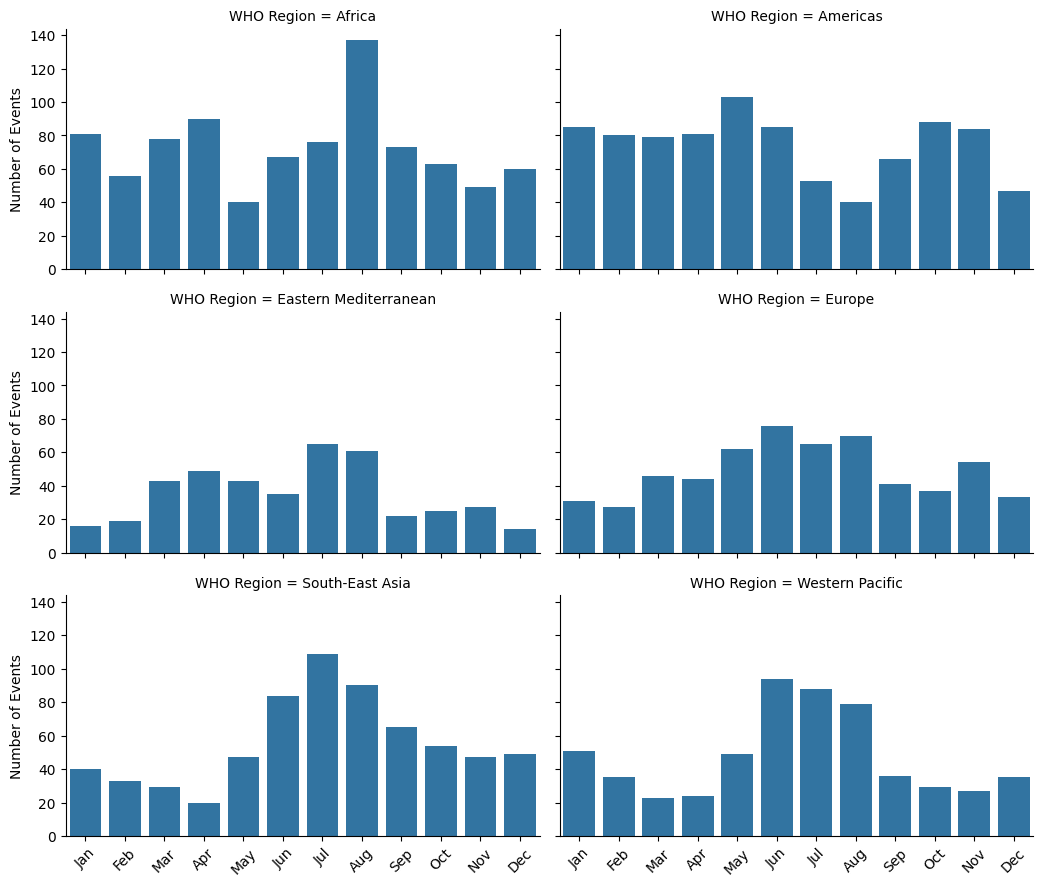

In [7]:
floods_monthly = floods_region_monthly.groupby(['WHO Region', 'Start Month'])['Number_of_Events'].sum().reset_index()

floods_monthly['Start Month'] = floods_monthly['Start Month'].astype(int)
floods_monthly['Month_Abbrev'] = floods_monthly['Start Month'].apply(lambda x: calendar.month_abbr[x])

g = sns.catplot(
    data=floods_monthly,
    x='Month_Abbrev',
    y='Number_of_Events',
    col='WHO Region',
    col_wrap=2,
    kind='bar',
    height=3,
    aspect=1.75,
    sharey=True
)
for ax in g.axes.flatten():
    ax.set_xticks(range(len(calendar.month_abbr[1:]))) 
    ax.set_xticklabels(calendar.month_abbr[1:], rotation=45)

g.set_axis_labels("", "Number of Events")
plt.show()

### 1.3 `floods_region_annually`

`floods_region_annually` contains the data aggregated at the region-year level. For each combination of `WHO Region` and `Start Year`, we sum up the variables `Number_of_Events`, `Total_Affected` and `Total_Deaths`.

In [8]:
floods_region_annually = floods_region_monthly.groupby(
    ['WHO Region', 'Start Year'],
    as_index=False
).agg(
    Number_of_Events=('Number_of_Events', 'sum'),
    Total_Affected=('Total_Affected', 'sum'),
    Total_Deaths=('Total_Deaths', 'sum'),
    Population_Region=('Population_Region', 'first') 
)
floods_region_annually.head()

,WHO Region,Start Year,Number_of_Events,Total_Affected,Total_Deaths,Population_Region
0,Africa,2000,27,5338563.0,1162.0,6.652319e+08
1,Africa,2001,31,2748476.0,1561.0,6.797848e+08
2,Africa,2002,25,897672.0,368.0,6.954101e+08
3,Africa,2003,34,1074374.0,356.0,7.109169e+08
4,Africa,2004,24,705238.0,216.0,7.267424e+08


Now, the following two rates are calculated:

1. The rate of annually affected people by floods per 100'000 population (`Annual_Affected_Rate`) for each region,
$$\text{Annual\_Affected\_Rate} = \text{Total\_Affected} / \text{Population\_Region} * 100000 $$

2. The annaul mortality rate per 100'000 population (`Annual_Mortality`) for each region
$$\text{Annual\_Mortality} = \text{Total\_Deaths} / \text{Population\_Region} * 100000$$

In [9]:
floods_region_annually["Annual_Affected_Rate"] = (
    floods_region_annually["Total_Affected"]
    / floods_region_annually["Population_Region"]
    * 100_000
)

floods_region_annually["Annual_Mortality"] = (
    floods_region_annually["Total_Deaths"]
    / floods_region_annually["Population_Region"]
    * 100_000
)

floods_region_annually[:5]

,WHO Region,Start Year,Number_of_Events,Total_Affected,Total_Deaths,Population_Region,Annual_Affected_Rate,Annual_Mortality
0,Africa,2000,27,5338563.0,1162.0,6.652319e+08,802.511623,0.174676
1,Africa,2001,31,2748476.0,1561.0,6.797848e+08,404.315613,0.229632
2,Africa,2002,25,897672.0,368.0,6.954101e+08,129.085272,0.052918
3,Africa,2003,34,1074374.0,356.0,7.109169e+08,151.125109,0.050076
4,Africa,2004,24,705238.0,216.0,7.267424e+08,97.040987,0.029722


### 1.4 Time Series Plot
In the figure below, the time series of the logarithmized annual affected rate (blue) and the logarithmized annual mortality (orange) are plotted for each WHO region. The solid lines represent the observed rates, while the dashed lines show log-linear trends that we fitted for each outcome.

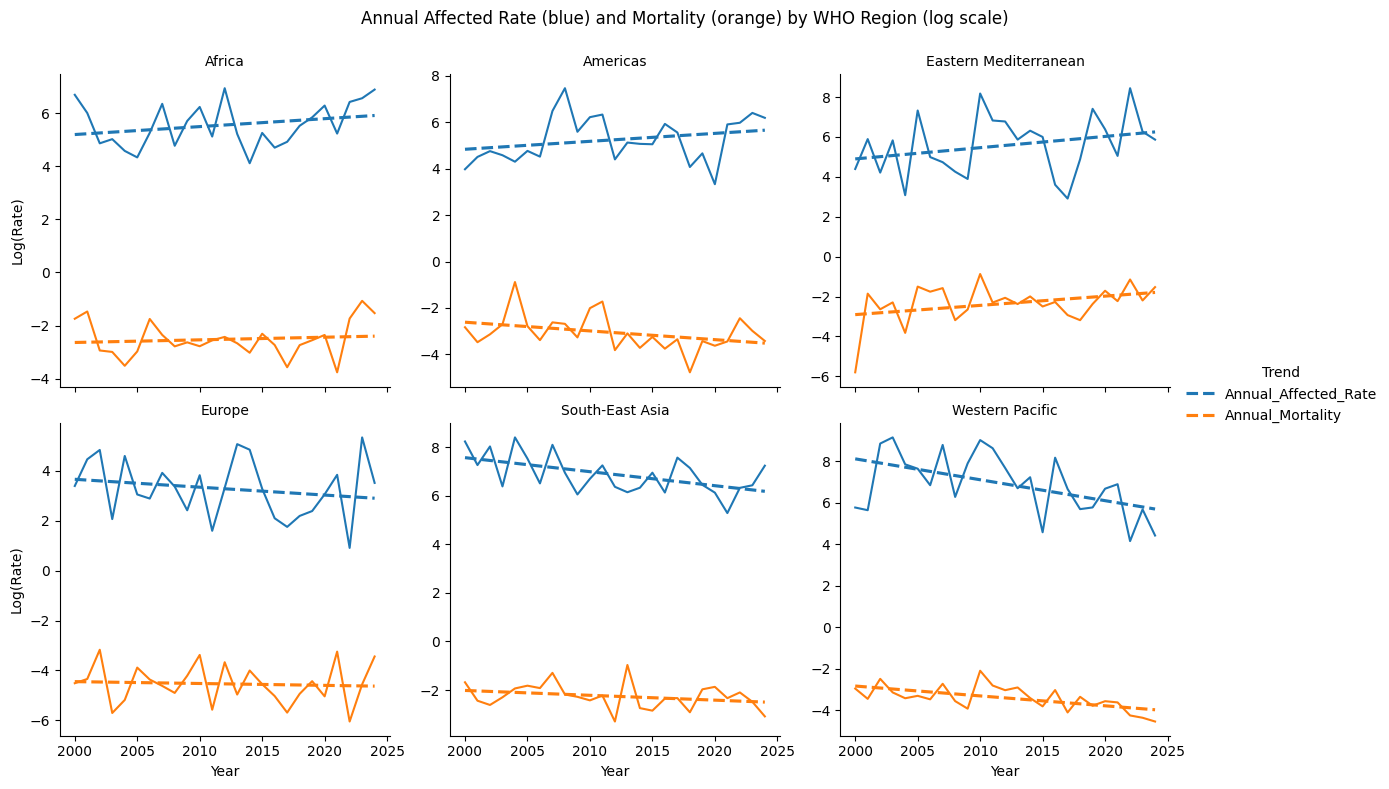

In [10]:
data_long = floods_region_annually.melt(
    id_vars=["Start Year", "WHO Region"],
    value_vars=["Annual_Affected_Rate", "Annual_Mortality"],
    var_name="Rate",
    value_name="Value"
)

data_long["LogValue"] = np.log(data_long["Value"] + 1e-6)  # it is common to add a small number inside the log to avoid taking log(0), which is undefined

g = sns.FacetGrid(data_long, col="WHO Region", hue="Rate", sharey=False, col_wrap=3, height=4)
g.map_dataframe(sns.lineplot, x="Start Year", y="LogValue")
g.map_dataframe(sns.regplot, x="Start Year", y="LogValue", scatter=False, ci=None, line_kws={"linestyle":"--"})

g.set_axis_labels("Year", "Log(Rate)")
g.set_titles("{col_name}")
g.add_legend(title="Trend")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Annual Affected Rate (blue) and Mortality (orange) by WHO Region (log scale)")

plt.show()

Examine the figure and interpret the trends. What patterns do you observe in the annual affected rate and mortality? How do these trends differ across WHO regions?

## 2. Estimated Annual Percentage Change (EAPC)

To formally quantify the trends you discussed in the previous task and test whether these trends are statistically significant, we calculate the Estimated Annual Percentage Change (EAPC) for both, the `Annual_Affected_Rate` and the `Annual_Mortality` constructed in the previous section. The EAPC quantifies the average yearly change in flood impact across different WHO regions. 

Mathematically, we can model the EAPCs with log-linear regression:
$$\log(y) = \alpha + \beta \cdot X + \epsilon,$$
where $y$ is either `Annual_Affected_Rate` or `Annual_Mortality`, $X$ is the `Start Year`, $\alpha$ is the expected value of $y$ when all explanatory variables are $0$ (the intercept), and $\beta$ is the regression coefficient (the slope). $\epsilon$ is the error term, i.e., the part of $y$ that cannot be explained by the model.

The function `calculate_eapc` is defined, which takes as input a dataset, a rate and a confidence level (default 0.05). It returns the EAPC, as defined in the formula above, as well as the (1- $\alpha$) confidence interval. Applying the function to `Annual_Affected_Rate` and `Annual_Mortality` from `floods_region_annually` yields the EAPC and the corresponding 95% confidence interval for the annual affected rate and the annual mortality.

In [14]:
def calculate_eapc(df, rate, alpha=0.05):

    y = np.log(df[rate])
    X = sm.add_constant(df["Start Year"])

    model = sm.OLS(y, X).fit()
    beta = model.params["Start Year"]

    eapc = 100 * (np.exp(beta) - 1)

    # Confidence interval
    conf = model.conf_int(alpha=alpha).loc["Start Year"]
    ci_lower = 100 * (np.exp(conf[0]) - 1)
    ci_upper = 100 * (np.exp(conf[1]) - 1)
     
    return pd.Series({"EAPC": eapc, "CI_Lower": ci_lower, "CI_Upper": ci_upper})


eapc_affected = floods_region_annually.groupby("WHO Region").apply(calculate_eapc, rate="Annual_Affected_Rate", include_groups = False)
eapc_mortality = floods_region_annually.groupby("WHO Region").apply(calculate_eapc, rate="Annual_Mortality", include_groups = False)

Based on Table 2 in Liu et al. (2024), we create a table showing the affected population and mortality caused by floods in 2000 and 2024 as well as the changes over time, by WHO region. More precisely, the 
- rows of the table represent the different WHO regions and
- columns of the table are
    1. `Annual_Affected_Rate` for the year 2000, 
    2. `Annual_Affected_Rate` for the year 2024, 
    3. EAPC and 95% CI for the `Annual_Affected_Rate`, 
    4. `Annual_Mortality` for the year 2000, 
    5. `Annual_Mortality` for the year 2024, 
    6. EAPC and 95% CI for the `Annual_Mortality`

In [16]:
rates_2000 = floods_region_annually[floods_region_annually["Start Year"] == 2000][
    ["WHO Region", "Annual_Affected_Rate", "Annual_Mortality"]
].rename(columns={"Annual_Affected_Rate": "Affected_Rate_2000", "Annual_Mortality": "Mortality_2000"})

rates_2024 = floods_region_annually[floods_region_annually["Start Year"] == 2024][
    ["WHO Region", "Annual_Affected_Rate", "Annual_Mortality"]
].rename(columns={"Annual_Affected_Rate": "Affected_Rate_2024", "Annual_Mortality": "Mortality_2024"})

rates_all = rates_2000.merge(rates_2024, on="WHO Region")

summary_table = rates_all.merge(
    eapc_affected.rename(columns={"EAPC": "EAPC_Affected", "CI_Lower": "CI_Lower_Affected", "CI_Upper": "CI_Upper_Affected"}),
    on="WHO Region"
).merge(
    eapc_mortality.rename(columns={"EAPC": "EAPC_Mortality", "CI_Lower": "CI_Lower_Mortality", "CI_Upper": "CI_Upper_Mortality"}),
    on="WHO Region"
)


summary_table["EAPC_Affected (95% CI)"] = summary_table.apply(
    lambda row: f"{row['EAPC_Affected']:.2f} ({row['CI_Lower_Affected']:.2f}, {row['CI_Upper_Affected']:.2f})", axis=1
)
summary_table["EAPC_Mortality (95% CI)"] = summary_table.apply(
    lambda row: f"{row['EAPC_Mortality']:.2f} ({row['CI_Lower_Mortality']:.2f}, {row['CI_Upper_Mortality']:.2f})", axis=1
)


final_table = summary_table[
    [
        "WHO Region",
        "Affected_Rate_2000", "Affected_Rate_2024", "EAPC_Affected (95% CI)",
        "Mortality_2000", "Mortality_2024", "EAPC_Mortality (95% CI)"
    ]
]

final_table

,WHO Region,Affected_Rate_2000,Affected_Rate_2024,EAPC_Affected (95% CI),Mortality_2000,Mortality_2024,EAPC_Mortality (95% CI)
0,Africa,802.511623,976.894775,"3.03 (-1.65, 7.94)",0.174676,0.215993,"1.00 (-2.88, 5.03)"
1,Americas,53.144025,485.918094,"3.48 (-2.12, 9.40)",0.059034,0.032701,"-3.68 (-7.65, 0.45)"
2,Eastern Mediterranean,81.098414,353.526294,"5.80 (-2.73, 15.08)",0.003029,0.217206,"4.74 (-0.73, 10.52)"
3,Europe,29.820480,33.735460,"-3.11 (-9.44, 3.66)",0.010965,0.032038,"-0.75 (-5.26, 3.98)"
4,South-East Asia,3746.278855,1383.585265,"-5.61 (-9.21, -1.86)",0.186216,0.045762,"-1.98 (-4.83, 0.97)"
5,Western Pacific,317.786838,82.412896,"-9.59 (-16.03, -2.65)",0.051609,0.010537,"-4.65 (-7.26, -1.98)"


Analyze the results. Based on the EAPC and the corresponding 95% confidence intervals, which WHO regions show statistically significant trends at the 5% significance level in flood-affected rates and mortality between 2000 and 2024? What are limitations of our statistical analysis?

**Hint**: A result is considered statistically significant at the 5% significance level if the 95% confidence interval does *not* include 0. If the 95% confidence interval *does* include 0, we cannot say that there is a significant increase or decrease in the rate over time.

## 3. Multivariable Logistic Regression Analysis

Lastly, a multivariable logistic regression analysis of factors associated with flood-related deaths is conducted. We are interested in analyzing which factors affect the number of deaths caused by flooding. The outcome variable (dependent variable) is a categorical encoding of the variable `Total Deaths` from the `floods` dataframe we loaded earlier. Specifically, the categories are
- 0 deaths (reference category)
- 1-9 deaths
- 10-49 deaths
- $>$ 50 deaths

The predictors (independent variables) are categorical encodings of the variables `Disaster Subtype`, `WHO Region` and `Start Year`. For the first two, we keep the original categories. We set "Flood (General)" and "Africa" as the reference categories. For `Start Year`, we define the following periods:
- 2000–2007 (reference category)
- 2008–2015
- 2016–2024


We will
 1. Encode the categories of the outcome variable and the predictors, ensuring that the reference categories are set as defined above.
 2. Fit a multinomial logistic regression using `sm.MNLogit`.
 3. Interpret the model output.

### 3.1 Data preparation

In this section, the following steps are done:
1. The outcome variable `Total Deaths Categorical` with categories "0 deaths", "1-9 deaths", "10-49 deaths", "> 50 deaths" is encoded. Missing values should belong to the category "0 deaths". 
2. The predictor `Start Period` with categories "2000–2007", "2008–2015", "2016–2024" is created.
3. All predictors are set as categorical.
4. The reference levels for the outcome variable as well as all predictors are set as previously defined.

In [17]:
floods["Total Deaths"] = floods["Total Deaths"].fillna(0)
floods["WHO Region"] = floods["WHO Region"].fillna("unknown")


# 1. Create the outcome variable 'Total Deaths Categorical'
floods["Total Deaths Categorical"] = pd.cut(
    floods["Total Deaths"],
    bins = [-np.inf, 0, 9, 49, np.inf],
    labels = ["0 deaths", "1-9 deaths", "10-49 deaths", "> 50 deaths"]
)

# 2. Create the predictor 'Start Period'
floods["Start Period"] = pd.cut(
    floods["Start Year"],
    bins=[1999, 2007, 2015, 2024],
    labels=["2000–2007", "2008–2015", "2016–2024"]
)

# 3. Ensure the predictors are categorical
floods["WHO Region"] = floods["WHO Region"].astype("category")
floods["Disaster Subtype"] = floods["Disaster Subtype"].astype("category")
floods["Start Period"] = floods["Start Period"].astype("category")


# 4. Chose the correct reference categories for each predictor
floods["Start Period"] = floods["Start Period"].cat.reorder_categories(
    ["2000–2007", "2008–2015", "2016–2024"]
)

floods["WHO Region"] = floods["WHO Region"].cat.reorder_categories(
    ["Africa", "Americas", "Eastern Mediterranean",
     "Europe", "South-East Asia", "Western Pacific", 
     "unknown"]
)

floods["Disaster Subtype"] = floods["Disaster Subtype"].cat.reorder_categories(
    ['Flood (General)', 'Coastal flood', 'Flash flood', 'Riverine flood']
)

print(floods["Total Deaths Categorical"].cat.categories)
print(floods["Start Period"].cat.categories)
print(floods["WHO Region"].cat.categories)
print(floods["Disaster Subtype"].cat.categories)

Index(['0 deaths', '1-9 deaths', '10-49 deaths', '> 50 deaths'], dtype='object')
Index(['2000–2007', '2008–2015', '2016–2024'], dtype='object')
Index(['Africa', 'Americas', 'Eastern Mediterranean', 'Europe',
       'South-East Asia', 'Western Pacific', 'unknown'],
      dtype='object')
Index(['Flood (General)', 'Coastal flood', 'Flash flood', 'Riverine flood'], dtype='object')


### 3.2 Logistic regression

The predictors are encoded using `get_dummies()`. The categories of the outcome variable are created using `cat.codes`. Then, we fit a logistic regression using `sm.MNLogit`.

In [18]:
X = pd.get_dummies(
    floods[["Start Period", "WHO Region", "Disaster Subtype"]],
    drop_first=True
).astype(int)

y = floods["Total Deaths Categorical"].astype("category").cat.codes

model = sm.MNLogit(y, sm.add_constant(X)).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 1.254612
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                 4126
Model:                        MNLogit   Df Residuals:                     4090
Method:                           MLE   Df Model:                           33
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.05900
Time:                        15:06:50   Log-Likelihood:                -5176.5
converged:                       True   LL-Null:                       -5501.1
Covariance Type:            nonrobust   LLR p-value:                1.845e-115
                             y=1       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.3742      0.150     -2.49

### 3.3 Interpretation

Mathematically, multinomial logistic regression can be expressed as the **log-odds**:
$$\log \frac{\Pr(Y = k \mid \mathbf{X} = \mathbf{x})}{\Pr(Y = 0 \mid \mathbf{X} = \mathbf{x})} = \beta_{0k} + \beta_k^\top \mathbf{x}, \quad k = 1, 2, 3,$$
where $Y=0$ is the reference category (in our case, no deaths), $\beta_{0k}$ is the intercept term for category $k$ and $\beta_k$ is the vector of coefficients for category $k$. Each $\beta_{kj}$ is a log-odds ratio, describing the change in log-odds of $Y = k$ against the reference category, $Y = 0$, if $X_j = 1$ compared to $X_j= 0$, holding all other predictors constant.

**Example**: Suppose $X_j$ is the dummy for "WHO Region = Europe" and the reference category is "WHO Region = Africa". Assume our model estimates $\hat{\beta}_{1j} = -0.0956$. This coefficient tells us the log-odds of $Y = 1$, 1-9 deaths, compared to $Y = 0$, no deaths, when the region is Europe instead of Africa. Exponentiating $\hat{\beta}_{1j}$ gives us the odds ratio:
$$\exp(\hat{\beta}_{1j}) = \exp(-0.0956) \approx 0.909$$
We get the following interpretation: The odds of having 1-9 deaths compared to 0 deaths are approximately 9% lower for floods in Europe than for floods in Africa, holding all other predictors constant.$^1$ 


Interpret the results of the multinomial logistic regression model. Which coefficients are significant at the 5% significance level ($p <0.05$)? How can we interpret these coefficients? What are potential explanations for these findings?

$^1$ You might wonder where the 9% come from. Getting an odds ratio of ca. 0.91 means that we multiply the odds for the reference category (e.g., Africa) with a factor 0.91 to get the odds for the category of interest (e.g., Europe):
$$\frac{\Pr(Y = k \mid X = \text{Europe})}{\Pr(Y = 0 \mid X = \text{Europe})} \approx 0.91 * \frac{\Pr(Y = k \mid X = \text{Africa})}{\Pr(Y = 0 \mid X = \text{Africa})}$$

This is equivalent to saying that the odds of $Y = k$ compared to $Y = 0$ for the category of interest are 9% lower than for the reference category.

You can have a look at this article for a more detailed interpretation of logistic regression coefficients: https://medium.com/data-science/a-simple-interpretation-of-logistic-regression-coefficients-e3a40a62e8cf